In [1]:
#importing required libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
#Reading data

df=pd.read_csv("/content/drive/MyDrive/student_performance/Mall_Customers.csv")

In [3]:
#tells no of rows and columns respectively

df.shape

(200, 5)

In [4]:
# tells column names
df.columns


Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
# datatype of every column
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [6]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


This is structured, tabular data since it is in table form having rows and columns where every column epresent a feautre and every row represent a new customer.

In this dataset we have 5 features.Among them,Gender  is categorical and remaining annual income and spending score , Age are numerical whereas customerid is identifier, not used as feature .


In [7]:
# descriptive analysis
features=["Age","Annual Income (k$)","Spending Score (1-100)"]
for feature in features:
  a=df[feature].mean()
  print("Mean of",feature,"is :",a)
  b=df[feature].median()
  print("Median of",feature,"is :",b)
  c=df[feature].std()
  print("Standard Deviation of",feature,"is :",c)

Mean of Age is : 38.85
Median of Age is : 36.0
Standard Deviation of Age is : 13.969007331558883
Mean of Annual Income (k$) is : 60.56
Median of Annual Income (k$) is : 61.5
Standard Deviation of Annual Income (k$) is : 26.264721165271254
Mean of Spending Score (1-100) is : 50.2
Median of Spending Score (1-100) is : 50.0
Standard Deviation of Spending Score (1-100) is : 25.823521668370162


Text(0.5, 1.0, 'Standard Deviation of Features')

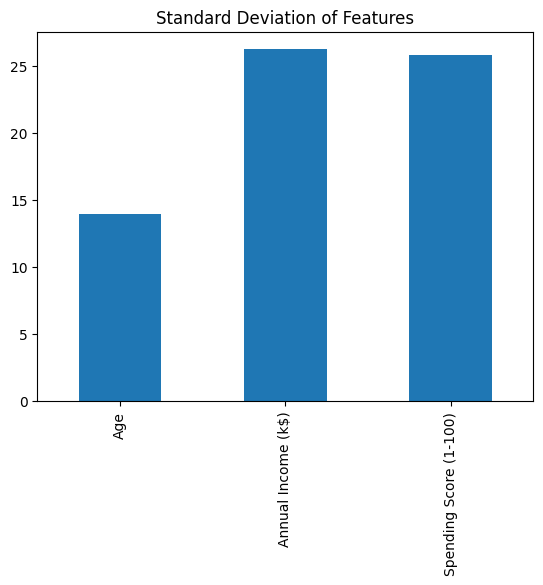

In [8]:
# For comparing standard dviation , for variability
features=["Age","Annual Income (k$)","Spending Score (1-100)"]

c=(df[features].std())
plt.figure()
c.plot(kind="bar")
plt.title("Standard Deviation of Features")

From observing above , we can see that annual income has most variability since it has most standard deviaton among all. which shows the spreadness of data.

Customers are somehow similar in agegroup it means that almost same age people are purchasing this ..but annual inccome and spending score shows hig diversty it means every income and spending  category is being covered in this...

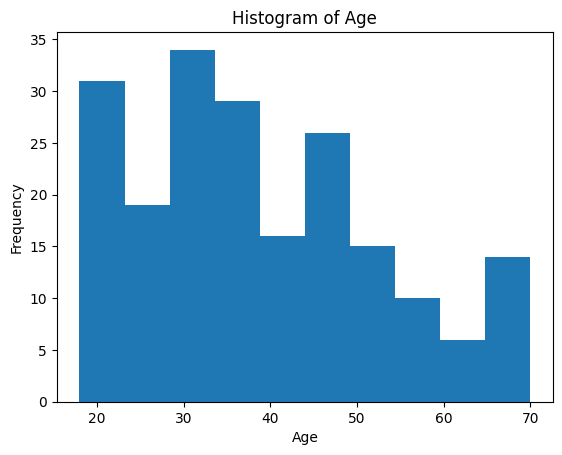

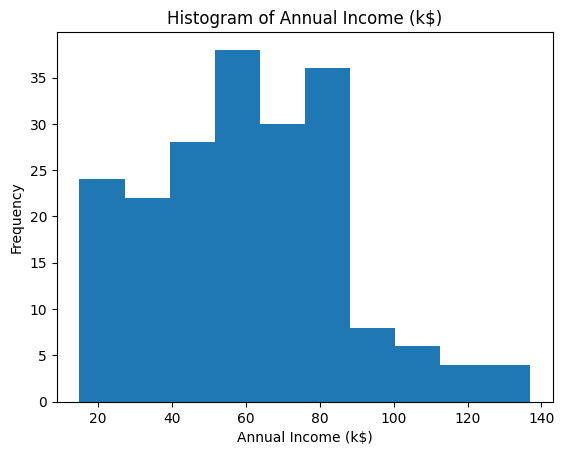

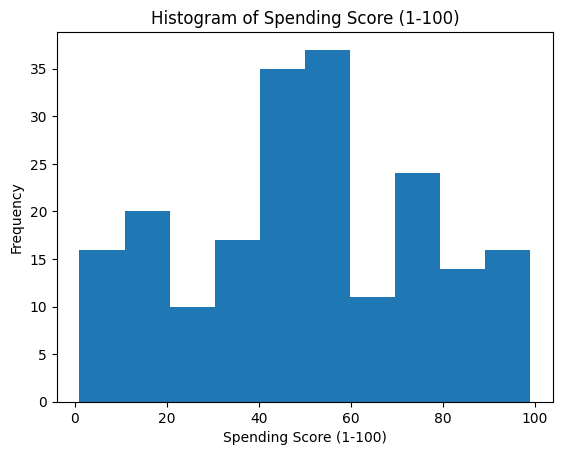

In [9]:
# Histogram of age,annual income and spending score

features=["Age","Annual Income (k$)","Spending Score (1-100)"]
for feature in features:
  df[feature].hist()
  plt.xlabel(feature)
  plt.ylabel("Frequency")
  plt.title(f"Histogram of {feature}")
  plt.grid(False)
  plt.show()




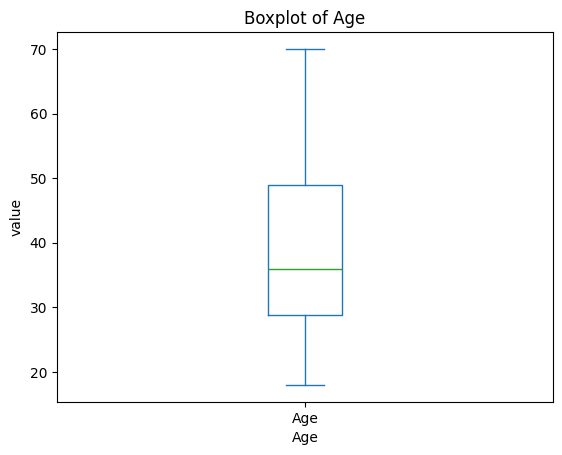

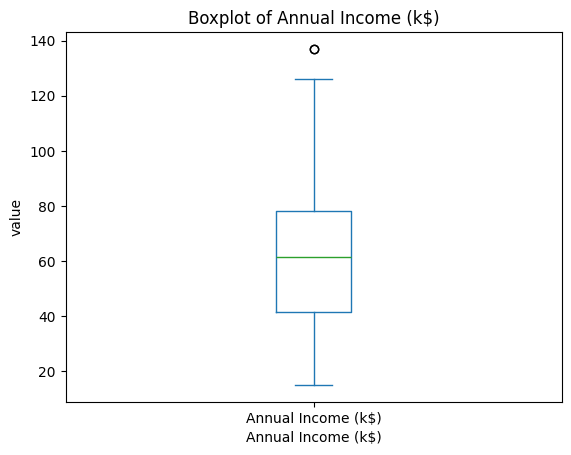

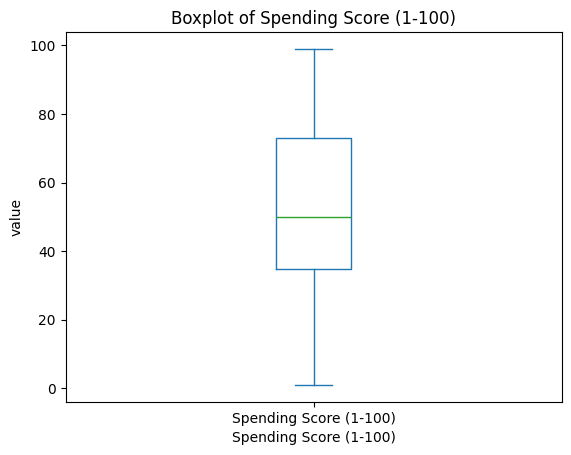

In [10]:
# Boxplot of age,annual income and spending score
features=["Age","Annual Income (k$)","Spending Score (1-100)"]
for feature in features:
  df[feature].plot(kind="box")
  plt.xlabel(feature)
  plt.ylabel("value")
  plt.title(f"Boxplot of {feature}")
  plt.show()


In [ ]:
# Average spending score on based of gender
a=df.groupby("Gender")['Spending Score (1-100)'].mean()
print(a)

Gender
Female    51.526786
Male      48.511364
Name: Spending Score (1-100), dtype: float64


**Skeweness** of data means that data is leannng towards one side  it shows that data is not symmetrical ,The distribution is  assymetric.
By observing boxplot and histogram ,we can find skeweness.
Since upper whisker of boxplot of **age** is longer than lower whisker showing **Postive skewness** / right skewness showing that more costumer are **younger than older**.
Similarly,by observing boxplot and histogram of **annual income**,  the distribution is **slightly positive skewed **because upper whisker is longer but median line is nearly centered which shows that** most customers have almost similar income level but few of them are significantly rich.**
Next is **spending score**, if we observe whisker we can say that distribution is negativily skewed since lower whisker is greater than upper whisker  but  if we see the median line  showing symmetry and hence no outlier so we can conclude that there is **no skewness** and hence **symmetrical** distriution. showing that amount of people who spend a lot is equal to amount of people who spend less.


While talking about extreme customers we have to talk about outliers in boxplot graph.
Since there is **no outlier** in boxplot graph of **spending score and age** showing that **no custtomer is extreme**. All customers belong to same group while talking about annual income, boxplot of **annual income have  outlier** not too much but ,having which shows that some** customers are extreme having significantly large annual income.**

In [11]:
#Average Income on based of gender
a=df.groupby("Gender")['Annual Income (k$)'].mean()
print(a)

Gender
Female    59.250000
Male      62.227273
Name: Annual Income (k$), dtype: float64


Males have earned more annual income than females.

But the difference is not significant , it is small , approx 3 k$ which shows that annual income is not significantly depend on gender.

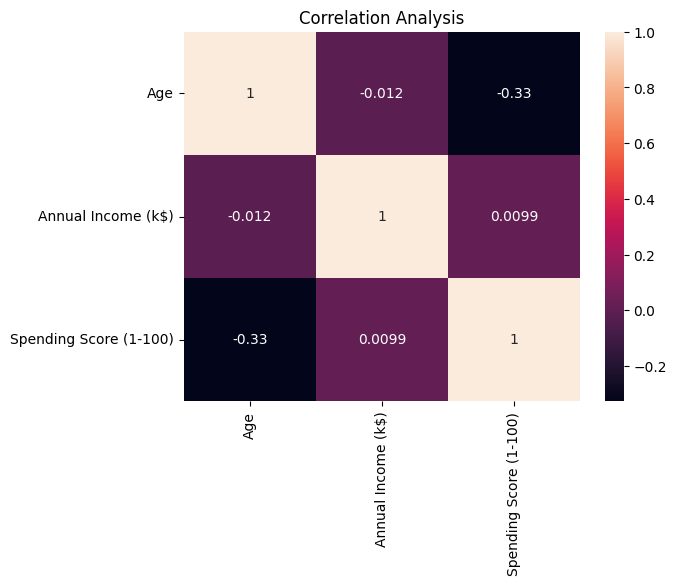

In [12]:
#Correlation Analysis
features=["Age","Annual Income (k$)","Spending Score (1-100)"]
corr=df[features].corr()
plt.figure()
sns.heatmap(corr,annot=True)
plt.title("Correlation Analysis")
plt.show()

By observing above correltion heatmap we can conclude that richer people( having high annual income)  does not decide or affect the  spending behaviour , like it maybe the richer pepole spend or maybe not.

**Yes**, age affects spending. by observing above correlation heatmap which shows the negative relation between age and spending ,we can conclude that as the age grows or the person becomes old , the spendings goes down .It simply meaans tht **Younger people spend more than older**.

In [13]:
# Do male and female customers spend differently?

#Hypothesis Test
# H0= There is no difference on spending based on  gender      (NULL Hypothesis)
# H1=There is significance difference

from scipy import stats


In [14]:
male=df[df["Gender"]=='Male']['Spending Score (1-100)']
female=df[df["Gender"]=='Female']['Spending Score (1-100)']
t_test,p_value=stats.ttest_ind(male,female)
print("p-value is :",p_value)
print("t-test-value is :",t_test)

if p_value<0.05:
  print("Reject Null Hypothesis")
else:
  print("Accept Null Hypothesis")

p-value is : 0.4137446589852174
t-test-value is : -0.8190464150660334
Accept Null Hypothesis


A p-value is the probabilty of obtaining results assuming that null hypothesis is true,and it helps determine weather the results is statistically significant or not. If p-value is high , it means that there is less probability of same reult as sample is showing(in sample, it maybe a coincidence),but if p-value is low ,it means there is high probability of same result as sample ,proven statistically.

Since  in our case p-value is 0.41 which is less than 0.5 which shows that there is **no significant difference** in spending behaviour  weather it is male or female,even in real population.

In [15]:
from math import sqrt
# confidence-interval
# for 95% , we know that Z score is 1.96

# confidence interval= mean pm(+,-) Z.(standard deviation/square root of sample size)

X=df["Spending Score (1-100)"].mean()
S=df["Spending Score (1-100)"].std()
n=len(df["Spending Score (1-100)"])
lower=X-(1.96*(S/sqrt(n)))
upper=X+(1.96*(S/sqrt(n)))
range=(int(lower),int(upper))
print("Confidence Interval is :",range)


Confidence Interval is : (46, 53)


 Average of spending score of  Customers fall into range (46,53)  

As the above result shows that we are 95% confident that every person from population will lie in above range from 46 to 53.

**Buiseness Insights**



*  For a buiseness, we should target customers which are** younger** as they tend to spend more and obviously with **high spending score** .As for annual income ,it doesnot affect spending behaviour directly but customers having **high annual income and high spending score will be best** for us and For Gender, as it does not affect significantly so **both male and female** will be welcomed.
* **NO**, For the given dataset, annual income doesnot depend on spending
* **No**, Marketing or spending does not significantly differ by Gender.Both male and Female spend approximate equally
* I would suggest a targeted marketing strategy based on customer segmentation using annual income and spending score. Customers with high income and high spending should be targeted with premium and luxury products, as they are the most valuable segment. Customers with low income but high spending can be targeted with discounts and promotional offers to maintain their engagement. Customers with high income but low spending represent an opportunity segment and can be encouraged through personalized offers, loyalty programs, and attractive deals like “buy one get one free.” Additionally, since younger customers tend to have higher spending behavior, marketing campaigns should be more trendy, digital, and youth-focused to maximize engagement.Along with this using social media effectively is also a great strategy.


